# Use the CMV ECOcluster to predict CMV status and HLA type

Demonstrate the CMV ECOcluster's ability to predict CMV status and explore the ability to predict HLA allele status among CMV+ donors, all using the 2016 'Emerson' cohorts.

## Takeaways from this post

* The CMV ECOcluster is a very good predictor of CMV status, even without accounting for donor HLA type
* But donor HLA type does matter; diagnostic performance is worse on Asian or Pacific Islander donors
* Among CMV+ donors, the CMV ECOcluster can be used to predict HLA allele status for many alleles with good sensitivity at essentially perfect specificity

In [6]:
# useful imports
import pandas as pd
from matplotlib import pyplot as plt

import itables
import seaborn as sns
from cmvividly.plots.style import set_style
set_style()

import itables
itables.init_notebook_mode()

#stats
from scipy.stats import mannwhitneyu

## Load previously saved files related to the "Emerson" datasets

The TCR repertoires from the two ["Emerson"](https://www.nature.com/articles/ng.3822) cohorts are available through Adaptive's ImmuneAccess portal. I downloaded the data, extracted the sample metadata and intersected the repertoire TCRs with the CMV ECOcluster, in [this notebook](https://github.com/dhmay/CMVividly/blob/main/notebooks/download_emerson.ipynb).

Let's load those processed files and prepare them for analysis.

In [7]:
from cmvividly.data.access import load_emerson_metadata
pdf_sample_metadata = load_emerson_metadata()
print("'Emerson' cohort breakdown by CMV status:")
pd.crosstab(pdf_sample_metadata.cohort,
            pdf_sample_metadata.cmv_status)


'Emerson' cohort breakdown by CMV status:


cmv_status  0.0  1.0
cohort              
cohort_1    352  289
cohort_2     68   51

In [8]:
from cmvividly.data.access import load_cmv_ecocluster_intersect_emerson
pdf_tcr_matches_2026 = load_cmv_ecocluster_intersect_emerson()
print("A sample of the TCR intersection of the CMV ECOcluster with the 'Emerson' repertoires:")
pdf_tcr_matches_2026

A sample of the TCR intersection of the CMV ECOcluster with the 'Emerson' repertoires:


sample_name  templates  productive_frequency  \
0             P00076        NaN              0.000052   
1             P00076        NaN              0.000098   
2             P00076        NaN              0.000020   
3             P00076        NaN              0.000089   
4             P00076        NaN              0.000109   
...              ...        ...                   ...   
148103  Keck0094_MC1        1.0              0.000002   
148104  Keck0094_MC1        1.0              0.000002   
148105  Keck0094_MC1        1.0              0.000002   
148106  Keck0094_MC1        1.0              0.000002   
148107  Keck0094_MC1        1.0              0.000002   

                                tcr_repertoire vgene_repertoire  \
0       CASSYGRVANTGELFF+TCRBV06-06+TCRBJ02-02       TCRBV06-06   
1       CASSLDTGQRNQPQHF+TCRBV05-05+TCRBJ01-05    TCRBV05-05*01   
2         CASSSEWGTDTQYF+TCRBV05-05+TCRBJ02-03    TCRBV05-05*01   
3         CASSEGQGDSPLHF+TCRBV05-01+TCRBJ01-06    TCRBV05-01*01   
4          CASSWGNTGELFF+TCRBV05-01+TCRBJ02-02    TCRBV05-01*01   
...                                        ...              ...   
148103       CSASGGRETQYF+TCRBV20-X+TCRBJ02-05          TCRBV20   
148104      CSAIQGSDSPLHF+TCRBV20-X+TCRBJ01-06          TCRBV20   
148105     CSAGERGLTDTQYF+TCRBV20-X+TCRBJ02-03          TCRBV20   
148106    CSARDRQLAKNIQYF+TCRBV20-X+TCRBJ02-04          TCRBV20   
148107      CSARVGGGETQYF+TCRBV20-X+TCRBJ02-05          TCRBV20   

       jgene_repertoire              cdr3  \
0         TCRBJ02-02*01  CASSYGRVANTGELFF   
1         TCRBJ01-05*01  CASSLDTGQRNQPQHF   
2         TCRBJ02-03*01    CASSSEWGTDTQYF   
3         TCRBJ01-06*01    CASSEGQGDSPLHF   
4         TCRBJ02-02*01     CASSWGNTGELFF   
...                 ...               ...   
148103    TCRBJ02-05*01      CSASGGRETQYF   
148104    TCRBJ01-06*01     CSAIQGSDSPLHF   
148105    TCRBJ02-03*01    CSAGERGLTDTQYF   
148106    TCRBJ02-04*01   CSARDRQLAKNIQYF   
148107    TCRBJ02-05*01     CSARVGGGETQYF   

                                tcr_ecocluster vgene_ecocluster  \
0       CASSYGRVANTGELFF+TCRBV06-06+TCRBJ02-02       TCRBV06-06   
1       CASSLDTGQRNQPQHF+TCRBV05-05+TCRBJ01-05       TCRBV05-05   
2         CASSSEWGTDTQYF+TCRBV05-05+TCRBJ02-03       TCRBV05-05   
3         CASSEGQGDSPLHF+TCRBV05-01+TCRBJ01-06       TCRBV05-01   
4          CASSWGNTGELFF+TCRBV05-01+TCRBJ02-02       TCRBV05-01   
...                                        ...              ...   
148103       CSASGGRETQYF+TCRBV20-X+TCRBJ02-05        TCRBV20-X   
148104      CSAIQGSDSPLHF+TCRBV20-X+TCRBJ01-06        TCRBV20-X   
148105     CSAGERGLTDTQYF+TCRBV20-X+TCRBJ02-03        TCRBV20-X   
148106    CSARDRQLAKNIQYF+TCRBV20-X+TCRBJ02-04        TCRBV20-X   
148107      CSARVGGGETQYF+TCRBV20-X+TCRBJ02-05        TCRBV20-X   

       jgene_ecocluster                    hla hla_class      tcr_pgen  \
0            TCRBJ02-02             DRB1*11:03       cii  1.656307e-10   
1            TCRBJ01-05                B*40:01        ci  2.116287e-11   
2            TCRBJ02-03             DRB3*02:02       cii  7.981617e-11   
3            TCRBJ01-06  DQA1*01:02+DQB1*06:02       cii  1.077448e-09   
4            TCRBJ02-02                B*40:01        ci  4.219798e-08   
...                 ...                    ...       ...           ...   
148103       TCRBJ02-05  DPA1*01:03+DPB1*02:01       cii  6.159549e-08   
148104       TCRBJ01-06  DPA1*01:03+DPB1*04:02       cii  2.232880e-10   
148105       TCRBJ02-03             DRB1*10:01       cii  1.802557e-10   
148106       TCRBJ02-04             DRB1*13:02       cii  2.818844e-09   
148107       TCRBJ02-05             DRB1*07:01       cii  3.690786e-08   

        log10_tcr_pgen_eps               hla_cocluster  \
0                -9.780859            h-DRB1_11_03-144   
1               -10.674425               h-B_40_01-223   
2               -10.097909             h-DRB3_02_02-99   
3                -8.967604   h-DQA1_01_02_DQB1_06_02

## Summarize the intersection per sample

Let's evaluate three metrics on their ability to separate CMV+ from CMV- donors:

* match count (n_matches): the number of TCRs in the sample that match the CMV ECOcluster
* breadth: the fraction of TCRs in the sample that match the CMV ECOcluster
* depth: the sum of productive frequencies of TCRs in the sample that match the CMV ECOcluster

In [9]:
# count matches per row
import numpy as np
pdf_tcrmatch_rowcounts = pdf_tcr_matches_2026.groupby("sample_name").agg({
    "tcr_repertoire": "count",
    "productive_frequency": "sum"
}).reset_index()
pdf_tcrmatch_rowcounts.columns = ["sample_name", "n_matches", "depth"]
pdf_exactmatch_rowcounts_withmeta = pdf_sample_metadata.merge(pdf_tcrmatch_rowcounts, how="left", on="sample_name").fillna(0)
pdf_exactmatch_rowcounts_withmeta["breadth"] = pdf_exactmatch_rowcounts_withmeta["n_matches"] / pdf_exactmatch_rowcounts_withmeta["productive_rearrangements"]

# add log10-transformed columns for plotting
# add an epsilon to breadth/depth for log10 transformation
EPS = 1e-4
pdf_exactmatch_rowcounts_withmeta["log10_breadth"] = np.log10(pdf_exactmatch_rowcounts_withmeta["breadth"] + EPS)
pdf_exactmatch_rowcounts_withmeta["log10_depth"] = np.log10(pdf_exactmatch_rowcounts_withmeta["depth"] + EPS)
pdf_exactmatch_rowcounts_withmeta

sample_name  cmv_status    cohort  productive_rearrangements     sex  \
0          P00076         1.0  cohort_1                      59552  Female   
1    Keck0076_MC1         1.0  cohort_2                     287910    Male   
2          P00402         1.0  cohort_1                     471962    Male   
3          P00655         0.0  cohort_1                     194142       0   
4    Keck0067_MC1         1.0  cohort_2                     153019    Male   
..            ...         ...       ...                        ...     ...   
781        P00654         0.0  cohort_1                     316695  Female   
782        P00089         1.0  cohort_1                     286828    Male   
783        P00364         1.0  cohort_1                     107819    Male   
784        P00066         0.0  cohort_1                     176729  Female   
785  Keck0094_MC1         0.0  cohort_2                     416728    Male   

                  ethnicity                       race  \
0         Unknown Ethnicity       Unknown racial group   
1    Non-Hispanic or Latino  Asian or Pacific Islander   
2    Non-Hispanic or Latino                  Caucasian   
3         Unknown Ethnicity       Unknown racial group   
4    Non-Hispanic or Latino  Asian or Pacific Islander   
..                      ...                        ...   
781  Non-Hispanic or Latino                  Caucasian   
782       Unknown Ethnicity       Unknown racial group   
783       Unknown Ethnicity       Unknown racial group   
784       Unknown Ethnicity       Unknown racial group   
785  Non-Hispanic or Latino                  Caucasian   

                                         Tissue Source   age  \
0    PBMC,Peripheral blood lymphocytes (PBL),T cell...  48.0   
1    PBMC,Peripheral blood lymphocytes (PBL),T cell...  27.0   
2    PBMC,Peripheral blood lymphocytes (PBL),T cell...  42.0   
3    PBMC,Peripheral blood lymphocytes (PBL),T cell...   0.0   
4    PBMC,Peripheral blood lymphocytes (PBL),T cell...  28.0   
..                                                 ...   ...   
781  PBMC,Peripheral blood lymphocytes (PBL),T cell...  58.0   
782  PBMC,Peripheral blood lymphocytes (PBL),T cell...  51.0   
783  PBMC,Peripheral blood lymphocytes (PBL),T cell...   0.0   
784  PBMC,Peripheral blood lymphocytes (PBL),T cell...  45.0   
785  PBMC,Peripheral blood lymphocytes (PBL),T cell...  29.0   

                             hla_class_i  n_matches     depth   breadth  \
0                                      0      264.0  0.011752  0.004433   
1                                      0      387.0  0.012810  0.001344   
2    HLA-A*03,HLA-A*26,HLA-B*38,HLA-B*44      599.0  0.003363  0.001269   
3             HLA-A*02,HLA-B*40,HLA-B*51      131.0  0.000745  0.000675   
4                                      0      135.0  0.001694  0.000882   
..                                   ...        ...       ...       ...   
781  HLA-A*24,HLA-A*29,HLA-B*44,HLA-B*57      183.0  0.000528  0.000578   
782  HLA-A*24,HLA-A*68,HLA-B*51,HLA-B*55      364.0  0.002542  0.001269   
783  HLA-A*26,HLA-A*30,HLA-B*13,HLA-B*35      160.0  0.004121  0.001484   
784  HLA-A*02,HLA-A*29,HLA-B*18,HLA-B*44       91.0  0.000427  0.000515   
785                                    0      232.0  0.000447  0.000557   

     log10_breadth  log10_depth  
0        -2.343605    -1.926224  
1        -2.840382    -1.889078  
2        -2.863543    -2.460584  
3        -3.110831    -3.073262  
4        -3.007781    -2.746235  
..             ...          ...  
781      -3.168871    -3.202122  
782      -2.863580    -2.578049  
783      -2.800253    -2.374614  
784      -3.211187    -3.277852  
785      -3.182621    -3.261639  

[786 rows x 15 columns]

## Visualize the intersection by cohort and CMV status

Let's visualize the difference in this intersection between CMV+ and CMV- donors. Three metrics:
* match count (n_matches): the number of TCRs in the sample that match the CMV ECOcluster
* breadth: the fraction of TCRs in the sample that match the CMV ECOcluster
* depth: the sum of productive frequencies of TCRs in the sample that match the CMV ECOcluster

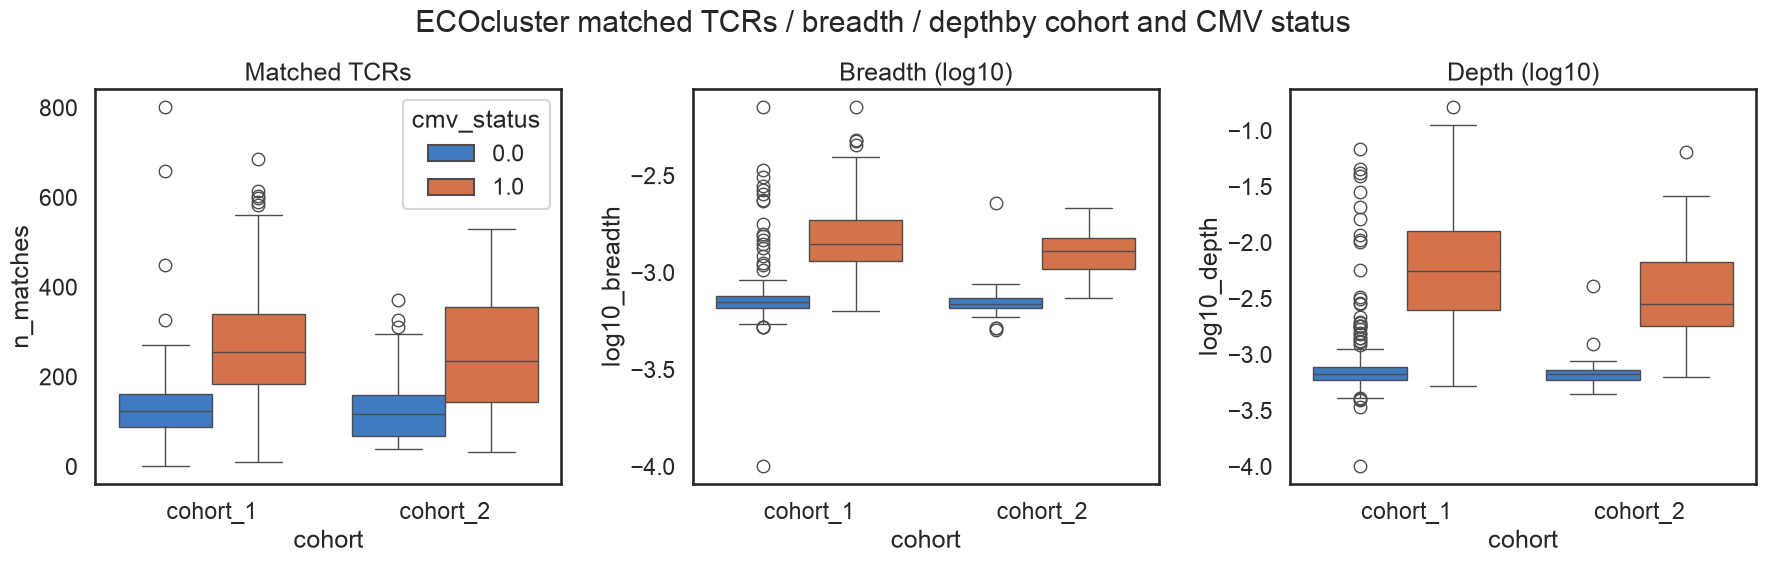

In [10]:
# boxplot of matches by CMV status
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=pdf_exactmatch_rowcounts_withmeta, x="cohort", y="n_matches", hue="cmv_status", ax=ax1)
ax1.set_title("Matched TCRs")
sns.boxplot(data=pdf_exactmatch_rowcounts_withmeta, x="cohort", y="log10_breadth", hue="cmv_status", ax=ax2)
ax2.set_title("Breadth (log10)")
# hide ax2's legend
ax2.get_legend().remove()
sns.boxplot(data=pdf_exactmatch_rowcounts_withmeta, x="cohort", y="log10_depth", hue="cmv_status", ax=ax3)
ax3.set_title("Depth (log10)")
ax3.get_legend().remove()

f.suptitle("ECOcluster matched TCRs / breadth / depthby cohort and CMV status", y=0.95)
f.tight_layout()


All three metrics show separation, but breadth and depth, which account for sequencing depth, show far better separation than match count.

### Assess diagnostic performance

Build ROC curves using match count, breadth and depth.

Text(0.5, 1.0, 'ROC curves predicting CMV status\nusing raw match count, breadth and depth')

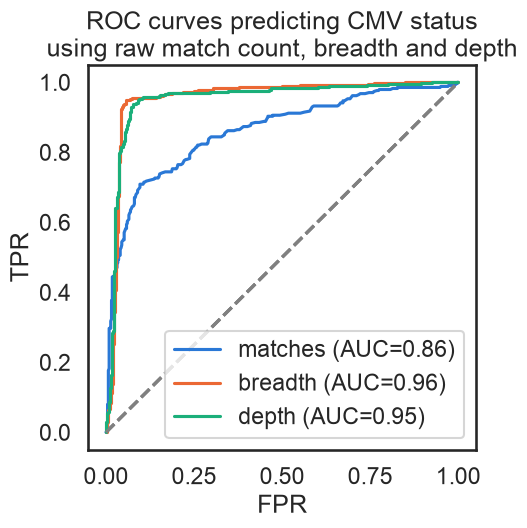

In [11]:
from cmvividly.plots.roc_utils import plot_roc, calc_auroc
f, ax = plt.subplots(figsize=(5, 5))

auroc_matches = calc_auroc(pdf_exactmatch_rowcounts_withmeta, "n_matches", "cmv_status")
auroc_breadth = calc_auroc(pdf_exactmatch_rowcounts_withmeta, "breadth", "cmv_status")
auroc_depth = calc_auroc(pdf_exactmatch_rowcounts_withmeta, "depth", "cmv_status")

plot_roc(pdf_exactmatch_rowcounts_withmeta, "n_matches", label_col="cmv_status", ax=ax, label=f"matches (AUC={auroc_matches:.2f})")
plot_roc(pdf_exactmatch_rowcounts_withmeta, "breadth", label_col="cmv_status", ax=ax, label=f"breadth (AUC={auroc_breadth:.2f})")
plot_roc(pdf_exactmatch_rowcounts_withmeta, "depth", label_col="cmv_status", ax=ax, label=f"depth (AUC={auroc_depth:.2f})")
ax.set_title("ROC curves predicting CMV status\nusing raw match count, breadth and depth")

So, after accounting for repertoire depth in one of two ways, the ECOcluster is a *very good* predictor of CMV status, even though we haven't accounted for donor HLA type at all. 

### Break down performance by race

But that doesn't mean HLA doesn't matter, even for CMV diagnosis! Race is a loose but useful proxy for HLA type. The CMV ECOcluster was built on repertoires from a wide variety of donors, some explicitly sourced to increase donor diversity. Nevertheless, well over half were Caucasian. Let's see how these donors break down by the race reported in the metadata:

In [12]:
pdf_exactmatch_rowcounts_withmeta.race.value_counts()

race
Caucasian                           460
Unknown racial group                258
Asian or Pacific Islander            46
African Race                         11
Native American or Alaska Native     10
0                                     1
Name: count, dtype: int64

Those values are straight from the ImmuneAccess file. I'm not sure what race "0" means, so I'll leave that out. I'll also leave out the groups with very few donors.

We might expect to see the classifier do better on Caucasians than on other groups, because they share more alleles with the repertoires ECOclusters were built on. Let's take a look.

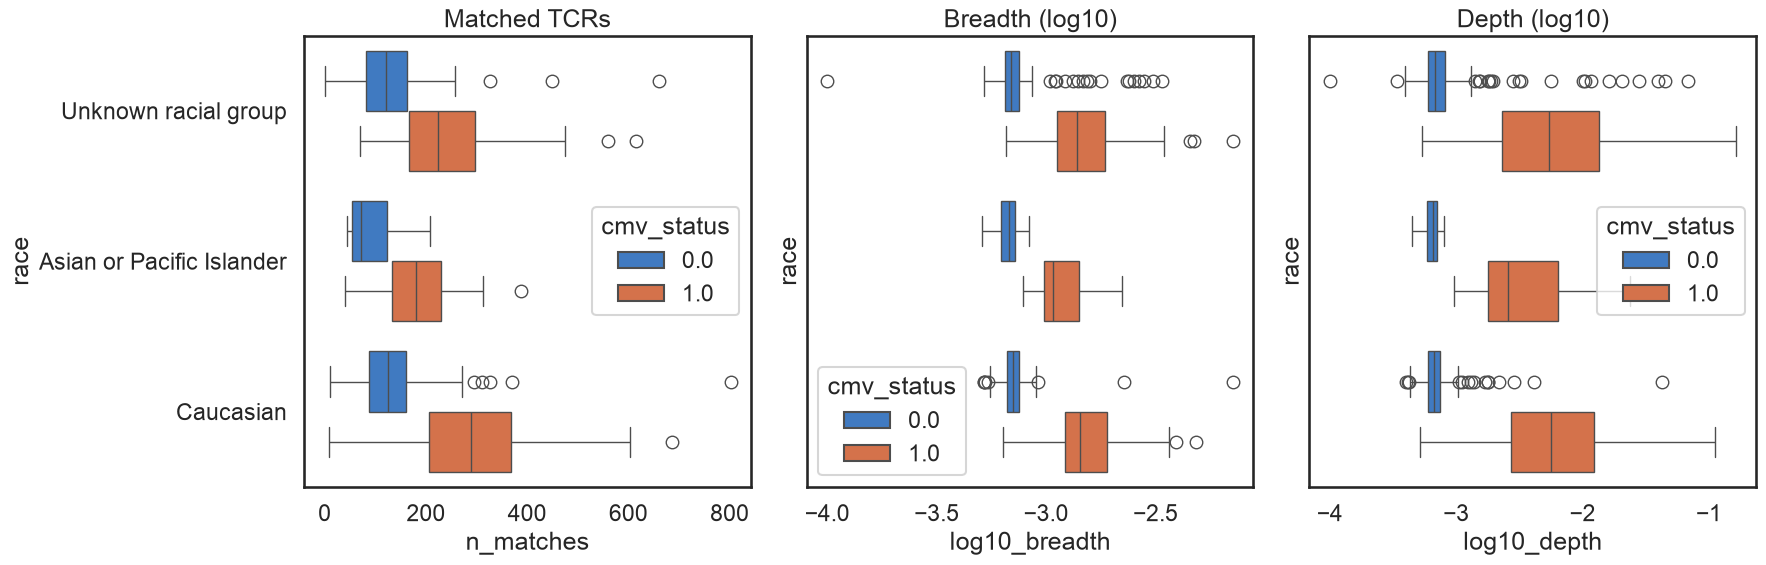

In [13]:
pdf_withrace_withenough = pdf_exactmatch_rowcounts_withmeta[
    (pdf_exactmatch_rowcounts_withmeta.race != 0)
    & (~pdf_exactmatch_rowcounts_withmeta.race.isin(["African Race", "Native American or Alaska Native"]))
]
   
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y="race", x="n_matches", hue="cmv_status", data=pdf_withrace_withenough, ax=ax1)
ax1.set_title("Matched TCRs")
sns.boxplot(y="race", x="log10_breadth", hue="cmv_status", data=pdf_withrace_withenough, ax=ax2)
ax2.set_yticks([])
ax2.set_title("Breadth (log10)")
sns.boxplot(y="race", x="log10_depth", hue="cmv_status", data=pdf_withrace_withenough, ax=ax3)
ax3.set_yticks([])
ax3.set_title("Depth (log10)")

f.tight_layout()

Visually, it looks like, among CMV+ donors, breadth, depth and # matches are all lower in the Asian or Pacific Islander group than in the other groups. Let's test for significance with a two-sided Mann-Whitney U test.

In [14]:
pdf_api = pdf_withrace_withenough[pdf_withrace_withenough.race == "Asian or Pacific Islander"]
pdf_notapi = pdf_withrace_withenough[pdf_withrace_withenough.race != "Asian or Pacific Islander"]
pdf_api_cmvpos = pdf_api[pdf_api.cmv_status == 1]
pdf_notapi_cmvpos = pdf_notapi[pdf_notapi.cmv_status == 1]

mwu_p_matches = mannwhitneyu(pdf_api_cmvpos.n_matches, pdf_notapi_cmvpos.n_matches).pvalue
mwu_p_breadth = mannwhitneyu(pdf_api_cmvpos.breadth, pdf_notapi_cmvpos.breadth).pvalue
mwu_p_depth = mannwhitneyu(pdf_api_cmvpos.depth, pdf_notapi_cmvpos.depth).pvalue

print(f"Two-sided MWU p-values:")
print(f"# matches: {mwu_p_matches:.1e}")
print(f"breadth: {mwu_p_breadth:.1e}")
print(f"depth: {mwu_p_depth:.1e}")
    

Two-sided MWU p-values:
# matches: 6.2e-05
breadth: 1.7e-04
depth: 4.9e-03


Yes, these differences are highly significant, particularly for match count and breadth.

Let's take a look at ROC curves *within* each group:

Text(0.5, 1.0, 'ROC curves predicting CMV status\nusing breadth, by race')

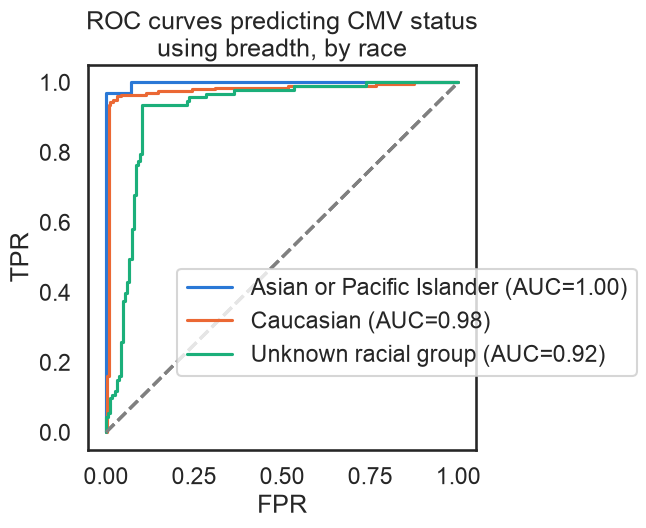

In [15]:
f, ax = plt.subplots(figsize=(5, 5))
for race in sorted(pdf_withrace_withenough.race.unique().tolist()):
    pdf_race = pdf_withrace_withenough[pdf_withrace_withenough.race == race]
    auroc_matches = calc_auroc(pdf_race, "breadth", "cmv_status")
    plot_roc(pdf_race, "breadth", label_col="cmv_status", label=f"{race} (AUC={auroc_matches:.2f})", ax=ax)
ax.legend(bbox_to_anchor=(0.2, 0.5), loc='upper left')
ax.set_title("ROC curves predicting CMV status\nusing breadth, by race")

We do markedly worse for the Unknown racial group due to a number of CMV- donors with very high breadth. There are a lot of people in that group, so the difference isn't likely due to chance. More likely, those donors have HLA alleles whose CMV-COclusters aren't as well differentiated w.r.t. CMV status and lack other alleles that are better differentiated.

Also, from the boxplots and MWU tests above, we also know that, if we throw all those donors together, API CMV+ donors will be less well-separated from CMV- donors of other races.

## Inferring donor CMV+ donor HLA type from the TCR repertoire

Can we get something *useful* out of the HLA-bound nature of the CMV TCRs? Can we use it to infer the status of CMV+ donors with respect to the HLA alleles present in the CMV ECOcluster?

If we consider two CMV+ donors, one with HLA allele `A*02:01` and one without, only the first donor should have `A*02:01`-associated TCRs responding to CMV. Since the CMV ECOcluster records the HLA allele associated with each TCR, we can use the `A*02:01`-associated CMV ECOcluster TCRs in a CMV+ donor's repertoire to predict whether that donor has `A*02:01`.

**Limitations:**

* All we've got is Class I HLA type, for a subset of donors, so we're entirely blind to Class II
    * (I think the full HLA types for these donors might be floating around somewhere? If you know how to get them, let me know and I'll redo all this!)
* The HLA metadata has values like `HLA-A*01`, while the HLA-COclusters in the CMV ECOcluster are associated with alleles like `A*01:01`. My workaround here will be to add `:01` to the end of the HLA metadata values and see if any HLA-COclusters match. That's a bit of a hack, and I might be missing some modelable alleles this way, but it demonstrates the idea.

Number of CMV+ donors with HLA Class I data: 274
HLA Class I alleles present among CMV+ donors: 59


Text(0.5, 1.0, 'CMV+ donor counts per Class I allele')

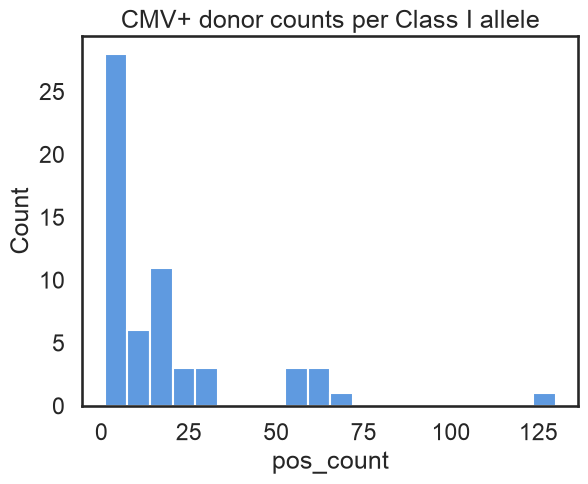

In [16]:
pdf_sample_metadata_withhla = pdf_sample_metadata[pdf_sample_metadata.hla_class_i.notnull()]
pdf_sample_metadata_withhla_cmvpos = pdf_sample_metadata_withhla[pdf_sample_metadata_withhla.cmv_status == 1]
print(f"Number of CMV+ donors with HLA Class I data: {len(pdf_sample_metadata_withhla_cmvpos)}")

all_alleles = set()
for hla_str in pdf_sample_metadata_withhla_cmvpos.hla_class_i:
    alleles = hla_str.split(",")
    all_alleles.update([x for x in alleles if x != "HLA MHC Class I"])  # there's some malformed metadata in there.
print(f"HLA Class I alleles present among CMV+ donors: {len(all_alleles)}")

alleles = sorted(all_alleles)
pos_counts = []
neg_counts = []
for allele in sorted(all_alleles):
    pdf_sample_metadata_withhla[allele] = pdf_sample_metadata_withhla.hla_class_i.apply(lambda x: 1 if allele in str(x).split(",") else 0)
    pos_counts.append(pdf_sample_metadata_withhla[(pdf_sample_metadata_withhla[allele] == 1) & (pdf_sample_metadata_withhla.cmv_status == 1)].shape[0])
    neg_counts.append(pdf_sample_metadata_withhla[(pdf_sample_metadata_withhla[allele] == 1) & (pdf_sample_metadata_withhla.cmv_status == 0)].shape[0])

pdf_pos_neg_counts = pd.DataFrame({
    "allele": sorted(all_alleles),
    "pos_count": pos_counts,
    "neg_count": neg_counts
})

f, ax = plt.subplots()    
sns.histplot(data=pdf_pos_neg_counts, x="pos_count", ax=ax, bins=20)
ax.set_title("CMV+ donor counts per Class I allele")

A lot of those alleles have very few allele+ donors among the CMV+ donors. Luckily, we don't really need to train a model! We just need enough donors to *assess* breadth as a predictor of allele status. 

Let's require at least 10 CMV+ donors with that allele to assess breadth as a predictor of allele status.

In [17]:
alleles_enough_cmvpos = pdf_pos_neg_counts[pdf_pos_neg_counts.pos_count >= 10].allele.tolist()
print(f"Class I alleles with at least 10 CMV+ donors: {len(alleles_enough_cmvpos)}")
# eliminate alleles with no associated HLA-COcluster
alleles_enough_cmvpos_with_hlacocluster = [
    allele for allele in alleles_enough_cmvpos if allele[len("HLA-"):] + ":01" in pdf_tcr_matches_2026.hla.unique().tolist()
]
print(f"...and an associated HLA-COcluster: {len(alleles_enough_cmvpos_with_hlacocluster)}")


Class I alleles with at least 10 CMV+ donors: 28
...and an associated HLA-COcluster: 12


So, there are 12 or so alleles we can reasonably evaluate.

Let's evaluate breadth on the associated HLA-COcluster as a predictor for having each allele.

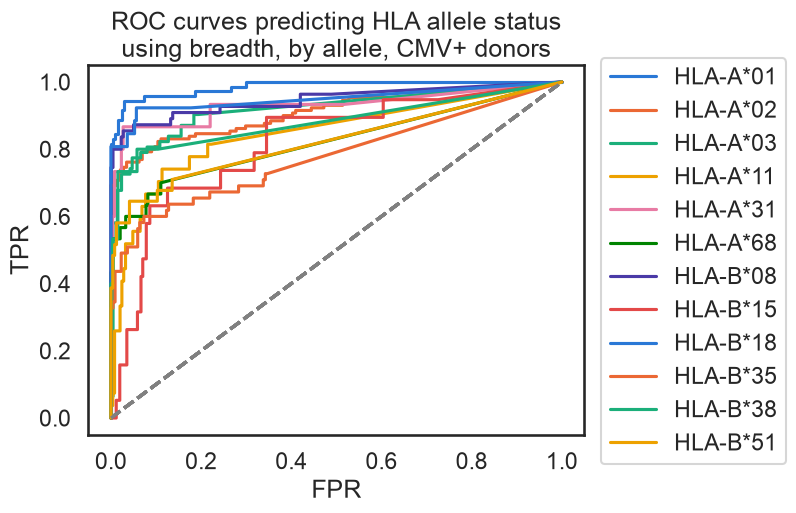

In [18]:
from cmvividly.plots.roc_utils import calc_roc_summary

pdf_tcr_matches_2026["hla_for_join"] = pdf_tcr_matches_2026.hla.apply(
    lambda x: x.split("*")[0])
# Join the HLA metadata with the breadth metric and assess breath as a predictor
pdf_sample_metadata_withhla_cmvpos = pdf_sample_metadata_withhla[pdf_sample_metadata_withhla.cmv_status == 1]


def calc_rocs_all_models(pdf_metadata, title_suffix):
    rows = []
    f, ax = plt.subplots()
    
    for allele in alleles_enough_cmvpos_with_hlacocluster:    
        allele_for_join = allele[len("HLA-"):] + ":01"
        pdf_matches_this_allele = pdf_tcr_matches_2026[pdf_tcr_matches_2026.hla == allele_for_join]
        pdf_rowcounts_this_allele = pdf_matches_this_allele.groupby("sample_name").agg({
            "tcr_repertoire": "count",
            "productive_frequency": "sum"
        }).reset_index()
        pdf_rowcounts_this_allele_withmeta = pdf_metadata.merge(
            pdf_rowcounts_this_allele, how="left", on="sample_name").fillna(0)
        pdf_rowcounts_this_allele_withmeta["breadth"] = pdf_rowcounts_this_allele_withmeta["tcr_repertoire"] / pdf_rowcounts_this_allele_withmeta["productive_rearrangements"]
        pdf_rowcounts_this_allele_withmeta["depth"] = pdf_rowcounts_this_allele_withmeta["productive_frequency"]
        auroc_breadth = calc_auroc(pdf_rowcounts_this_allele_withmeta, "breadth", label_col=allele)
        sens_98_spec_breadth = calc_roc_summary(pdf_rowcounts_this_allele_withmeta, "breadth", label_col=allele,
                                                specificities=[0.98])["senses_at_specs"][0]
        auroc_depth = calc_auroc(pdf_rowcounts_this_allele_withmeta, "depth", label_col=allele)
        rows.append({
            "allele": allele,
            "n_cmvpos": sum(pdf_rowcounts_this_allele_withmeta[allele] == 1),
            "auroc_breadth": auroc_breadth,
            "auroc_depth": auroc_depth,
            "sens_98_spec_breadth": sens_98_spec_breadth
        })
        plot_roc(pdf_rowcounts_this_allele_withmeta, 
                 "breadth", label_col=allele, ax=ax, label=allele)
    ax.set_title(f"ROC curves predicting HLA allele status\nusing breadth, by allele, {title_suffix}")
    ax.legend(bbox_to_anchor=(1.01, 1.05), loc='upper left')
    
    pdf_allele_aurocs = pd.DataFrame(rows).sort_values("auroc_breadth", ascending=False)
    return pdf_allele_aurocs

pdf_allele_aurocs_cmvpos = calc_rocs_all_models(pdf_sample_metadata_withhla_cmvpos, "CMV+ donors")


Let's take a look at the AUROCs and sensitivities at 98% specificity for those models.

allele  n_cmvpos  auroc_breadth  auroc_depth  sens_98_spec_breadth
0   HLA-A*01        71       0.985985     0.983071              0.887324
8   HLA-B*18        26       0.949132     0.944789              0.807692
6   HLA-B*08        55       0.945870     0.942715              0.800000
4   HLA-A*31        15       0.930116     0.900772              0.733333
2   HLA-A*03        62       0.917985     0.913421              0.677419
1   HLA-A*02       130       0.909348     0.908280              0.707692
10  HLA-B*38        15       0.882111     0.883655              0.733333
3   HLA-A*11        27       0.846304     0.859049              0.259259
11  HLA-B*51        31       0.823311     0.823975              0.580645
5   HLA-A*68        30       0.822199     0.820287              0.533333
7   HLA-B*15        19       0.817337     0.779979              0.157895
9   HLA-B*35        55       0.778373     0.787339              0.436364

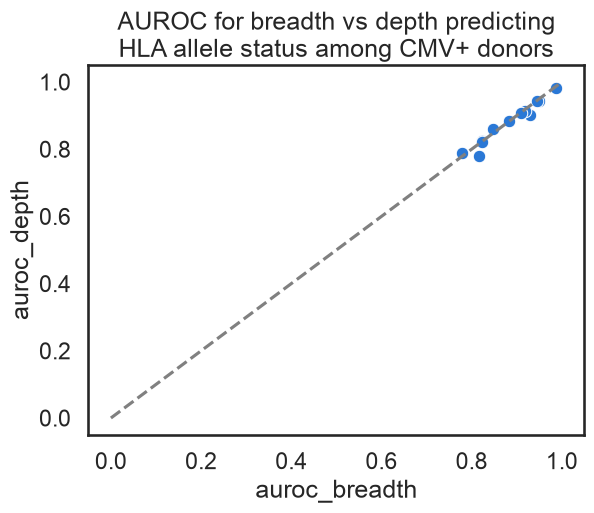

In [26]:
f, ax = plt.subplots()
sns.scatterplot(data=pdf_allele_aurocs_cmvpos, y="auroc_depth", x="auroc_breadth")
ax.set_title("AUROC for breadth vs depth predicting\nHLA allele status among CMV+ donors")
sns.lineplot(x=[0, 1], y=[0, 1], color="gray", linestyle="--", ax=ax)
pdf_allele_aurocs_cmvpos

AUROCs based on breadth and on depth are strikingly similar, with a slight advantage to breadth-based models.

Just to be sure, let's take a look at those same "models" in CMV- donors. There should be no signal, because those donors shouldn't have CMV-responding TCRs.

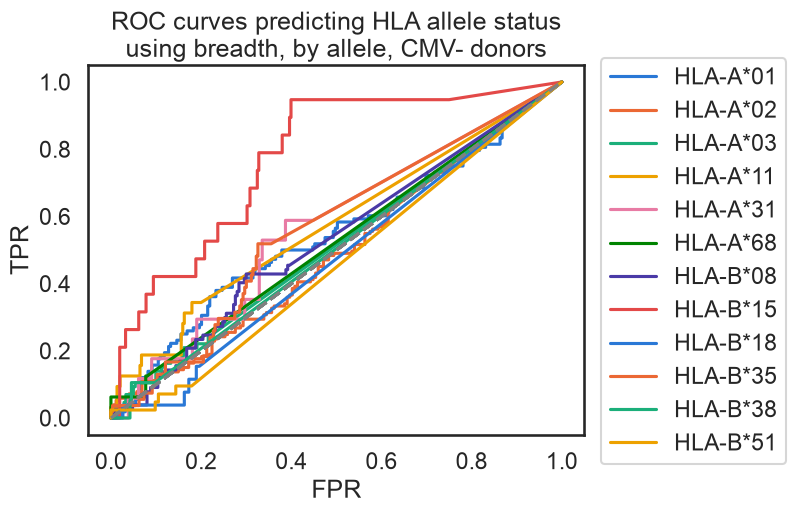

In [24]:
pdf_sample_metadata_withhla_cmvneg = pdf_sample_metadata_withhla[pdf_sample_metadata_withhla.cmv_status == 0]

pdf_allele_aurocs_cmvneg = calc_rocs_all_models(pdf_sample_metadata_withhla_cmvneg, "CMV- donors")

Huh! Most of the alleles are total garbage, as expected. But there's some signal in `A*01`. There's only one `A*01:01` HLA-COcluster in the CMV ECOcluster, but perhaps it's not totally "pure"... maybe it's dominated by CMV-specific TCRs, but some TCRs also respond to other exposures.

## Applications of HLA allele models usable on CMV+ donors

So, all but one of those "models" (HLA-B*35) has notable sensitivity at essentially perfect specificity, and they all have AUROC > 0.77. The best 6 models have >70% sensitivity at 98% specificity.

Quite likely, a number of the other alleles represented in the CMV ECOcluster have similar performance, but we don't have enough CMV+ donors with those alleles in this dataset to assess performance. And of course we haven't even been able to look at Class II alleles, since we didn't have any data there.

I think the best HLA allele models, combined with the CMV ECOcluster's ability to predict CMV status and enough public repertoires, could allow us to "pseudolabel" inferred CMV+ donors with status on those HLAs, learn signal from exposures other than CMV, and build HLA allele models that could be used on both CMV+ and CMV- donors.